In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

# Display settings
pd.set_option("display.max_columns", None)

# Plot style
sns.set_style("whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
np.random.seed(42)

n = 1000

shipment_id = [f"SHP{str(i).zfill(5)}" for i in range(1, n + 1)]

shipment_date = pd.date_range(
    start="2025-01-01",
    end="2025-12-31",
    periods=n
)

transport_mode = np.random.choice(
    ["Road", "Rail", "Air", "Sea"],
    size=n,
    p=[0.50, 0.20, 0.15, 0.15]
)

region = np.random.choice(
    ["North", "South", "East", "West", "Central"],
    size=n
)

distance_km = np.random.gamma(
    shape=3,
    scale=250,
    size=n
)

distance_km = np.clip(distance_km, 50, 2000)

shipment_volume = np.random.gamma(
    shape=4,
    scale=20,
    size=n
)

shipment_volume = np.clip(
    shipment_volume,
    5,
    250
)

# Mode-based cost per km
cost_per_km = np.select(
    [
        transport_mode == "Road",
        transport_mode == "Rail",
        transport_mode == "Air",
        transport_mode == "Sea"
    ],
    [
        1.8,
        1.2,
        4.5,
        0.9
    ]
)

transportation_cost = (
    distance_km * cost_per_km
    + shipment_volume * 8
    + np.random.normal(0, 150, n)
)

transportation_cost = np.maximum(
    transportation_cost,
    100
)

fuel_cost = (
    distance_km
    * np.random.uniform(0.18, 0.35, n)
)

fuel_cost = np.maximum(
    fuel_cost,
    20
)

# Base delivery time influenced by distance and mode
mode_time = np.select(
    [
        transport_mode == "Road",
        transport_mode == "Rail",
        transport_mode == "Air",
        transport_mode == "Sea"
    ],
    [
        2.5,
        4.5,
        1.2,
        7.0
    ]
)

delivery_time_days = (
    mode_time
    + distance_km / 350
    + shipment_volume / 180
    + np.random.normal(0, 1.5, n)
)

delivery_time_days = np.maximum(
    delivery_time_days,
    0.5
)

# Generate delivery delays
delay_days = np.random.normal(
    loc=0.5,
    scale=2.5,
    size=n
)

delay_days = np.maximum(
    delay_days,
    -2
)

delivery_status = np.where(
    delay_days > 0,
    "Delayed",
    "On-Time"
)

logistics_data = pd.DataFrame({
    "shipment_id": shipment_id,
    "shipment_date": shipment_date,
    "delivery_time_days": np.round(delivery_time_days, 2),
    "shipment_volume": np.round(shipment_volume, 2),
    "transportation_cost": np.round(transportation_cost, 2),
    "distance_km": np.round(distance_km, 2),
    "fuel_cost": np.round(fuel_cost, 2),
    "delay_days": np.round(delay_days, 2),
    "transport_mode": transport_mode,
    "region": region,
    "delivery_status": delivery_status
})

print("Dataset created successfully!")

Dataset created successfully!


In [3]:
print("Dataset Shape:", logistics_data.shape)

print("\nFirst 5 Records:")
display(logistics_data.head())

print("\nDataset Information:")
logistics_data.info()

Dataset Shape: (1000, 11)

First 5 Records:


,shipment_id,shipment_date,delivery_time_days,shipment_volume,transportation_cost,distance_km,fuel_cost,delay_days,transport_mode,region,delivery_status
0,SHP00001,2025-01-01 00:00:00.000000000,4.92,106.75,1085.43,85.16,20.36,0.68,Road,West,Delayed
1,SHP00002,2025-01-01 08:44:41.081081081,9.93,88.44,1450.43,627.72,185.67,1.63,Sea,East,Delayed
2,SHP00003,2025-01-01 17:29:22.162162162,2.38,49.82,3069.51,617.40,150.27,1.68,Air,Central,Delayed
3,SHP00004,2025-01-02 02:14:03.243243243,9.95,88.31,2087.19,1149.86,235.43,-0.41,Rail,North,On-Time
4,SHP00005,2025-01-02 10:58:44.324324324,3.87,35.49,1492.65,654.45,162.98,-0.86,Road,Central,On-Time



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   shipment_id          1000 non-null   object        
 1   shipment_date        1000 non-null   datetime64[ns]
 2   delivery_time_days   1000 non-null   float64       
 3   shipment_volume      1000 non-null   float64       
 4   transportation_cost  1000 non-null   float64       
 5   distance_km          1000 non-null   float64       
 6   fuel_cost            1000 non-null   float64       
 7   delay_days           1000 non-null   float64       
 8   transport_mode       1000 non-null   object        
 9   region               1000 non-null   object        
 10  delivery_status      1000 non-null   object        
dtypes: datetime64[ns](1), float64(6), object(4)
memory usage: 86.1+ KB


In [4]:
print("Statistical Summary:")
display(logistics_data.describe())

Statistical Summary:


,shipment_date,delivery_time_days,shipment_volume,transportation_cost,distance_km,fuel_cost,delay_days
count,1000,1000.000000,1000.00000,1000.000000,1000.00000,1000.000000,1000.000000
mean,2025-07-02 00:00:00,6.074660,78.88411,2058.763810,757.76877,201.161250,0.634610
min,2025-01-01 00:00:00,0.500000,7.59000,111.810000,50.00000,20.000000,-2.000000
25%,2025-04-02 00:00:00,4.070000,51.59250,1244.837500,434.48500,110.872500,-1.270000
50%,2025-07-02 00:00:00,6.015000,72.71500,1744.720000,678.11000,176.520000,0.385000
75%,2025-10-01 00:00:00,7.810000,101.01000,2498.925000,992.41000,257.300000,2.050000
max,2025-12-31 00:00:00,16.270000,248.53000,9427.680000,2000.00000,695.480000,8.190000
std,NaN,2.662663,38.69289,1211.394168,428.25377,122.787999,2.157966


In [5]:
print("Transport Mode Distribution:")
display(logistics_data["transport_mode"].value_counts())

print("\nRegion Distribution:")
display(logistics_data["region"].value_counts())

print("\nDelivery Status Distribution:")
display(logistics_data["delivery_status"].value_counts())

Transport Mode Distribution:


,count
transport_mode,
Road,503
Rail,209
Sea,153
Air,135



Region Distribution:


,count
region,
Central,214
South,212
West,208
North,193
East,173



Delivery Status Distribution:


,count
delivery_status,
Delayed,567
On-Time,433


In [6]:
print("Duplicate Records:", logistics_data.duplicated().sum())

print("Duplicate Shipment IDs:",
      logistics_data["shipment_id"].duplicated().sum())

Duplicate Records: 0
Duplicate Shipment IDs: 0


In [7]:
print("Average Delivery Time:",
      round(logistics_data["delivery_time_days"].mean(), 2), "days")

print("Average Shipment Volume:",
      round(logistics_data["shipment_volume"].mean(), 2))

print("Average Transportation Cost:",
      round(logistics_data["transportation_cost"].mean(), 2))

print("Average Distance:",
      round(logistics_data["distance_km"].mean(), 2), "km")

print("Average Fuel Cost:",
      round(logistics_data["fuel_cost"].mean(), 2))

print("Average Delay:",
      round(logistics_data["delay_days"].mean(), 2), "days")

Average Delivery Time: 6.07 days
Average Shipment Volume: 78.88
Average Transportation Cost: 2058.76
Average Distance: 757.77 km
Average Fuel Cost: 201.16
Average Delay: 0.63 days


In [8]:
status_percentage = (
    logistics_data["delivery_status"]
    .value_counts(normalize=True) * 100
)

print("Delivery Status Percentage:")
display(status_percentage.round(2))

Delivery Status Percentage:


,proportion
delivery_status,
Delayed,56.7
On-Time,43.3


In [9]:
numeric_columns = [
    "delivery_time_days",
    "shipment_volume",
    "transportation_cost",
    "distance_km",
    "fuel_cost",
    "delay_days"
]

correlation_matrix = logistics_data[numeric_columns].corr()

print("Correlation Matrix:")
display(correlation_matrix.round(2))

Correlation Matrix:


,delivery_time_days,shipment_volume,transportation_cost,distance_km,fuel_cost,delay_days
delivery_time_days,1.00,0.09,-0.02,0.45,0.43,0.02
shipment_volume,0.09,1.00,0.27,0.00,0.02,0.01
transportation_cost,-0.02,0.27,1.00,0.62,0.57,-0.03
distance_km,0.45,0.00,0.62,1.00,0.93,0.01
fuel_cost,0.43,0.02,0.57,0.93,1.00,0.01
delay_days,0.02,0.01,-0.03,0.01,0.01,1.00


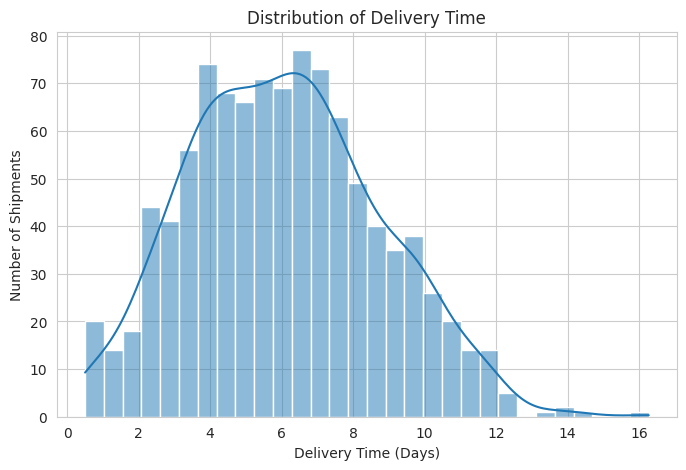

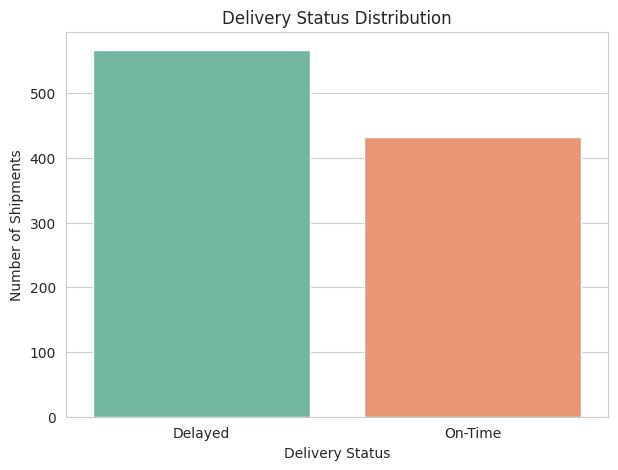

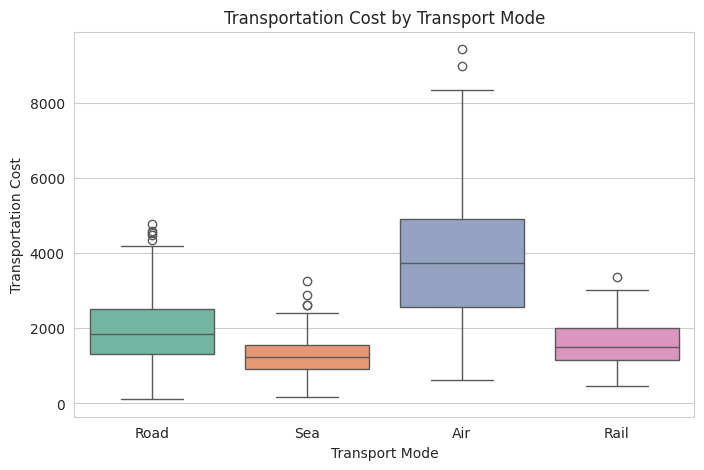

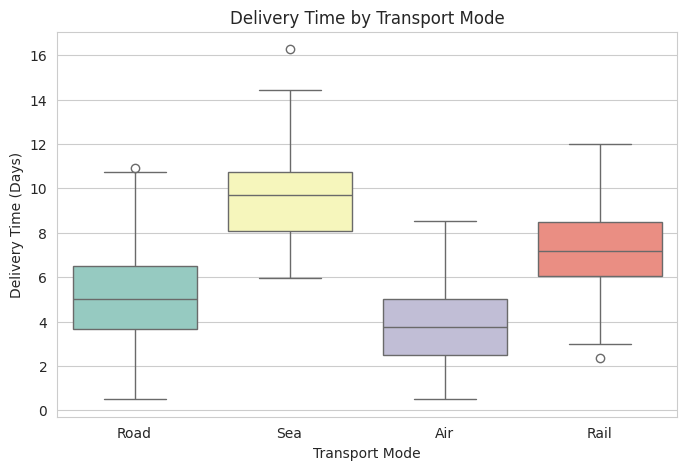

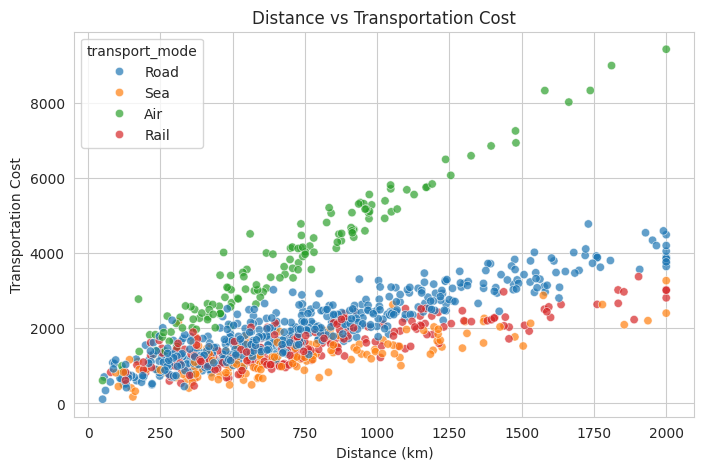

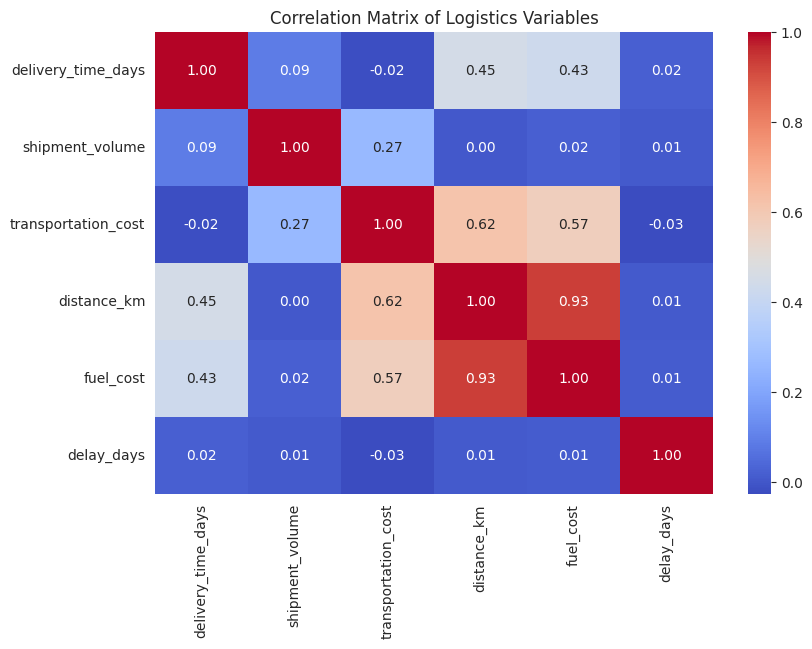

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# 1. Delivery Time Distribution
plt.figure(figsize=(8,5))
sns.histplot(logistics_data["delivery_time_days"], bins=30, kde=True)
plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Number of Shipments")
plt.show()


# 2. Delivery Status
plt.figure(figsize=(7,5))
sns.countplot(
    data=logistics_data,
    x="delivery_status",
    hue="delivery_status",
    palette="Set2",
    legend=False
)
plt.title("Delivery Status Distribution")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Shipments")
plt.show()


# 3. Transportation Cost by Transport Mode
plt.figure(figsize=(8,5))
sns.boxplot(
    data=logistics_data,
    x="transport_mode",
    y="transportation_cost",
    hue="transport_mode",
    palette="Set2",
    legend=False
)
plt.title("Transportation Cost by Transport Mode")
plt.xlabel("Transport Mode")
plt.ylabel("Transportation Cost")
plt.show()


# 4. Delivery Time by Transport Mode
plt.figure(figsize=(8,5))
sns.boxplot(
    data=logistics_data,
    x="transport_mode",
    y="delivery_time_days",
    hue="transport_mode",
    palette="Set3",
    legend=False
)
plt.title("Delivery Time by Transport Mode")
plt.xlabel("Transport Mode")
plt.ylabel("Delivery Time (Days)")
plt.show()


# 5. Distance vs Transportation Cost
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=logistics_data,
    x="distance_km",
    y="transportation_cost",
    hue="transport_mode",
    alpha=0.7
)
plt.title("Distance vs Transportation Cost")
plt.xlabel("Distance (km)")
plt.ylabel("Transportation Cost")
plt.show()


# 6. Correlation Heatmap
plt.figure(figsize=(9,6))
correlation = logistics_data[
    [
        "delivery_time_days",
        "shipment_volume",
        "transportation_cost",
        "distance_km",
        "fuel_cost",
        "delay_days"
    ]
].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Logistics Variables")
plt.show()